#Imports

##Project Dependencies

In [1]:
#Git
from getpass import getpass

#data analises
import matplotlib.pyplot as plt
import numpy as np

#pytorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

##Git Import

In [2]:
!git config --global user.name "marcos"
!git config --global user.email "marcosf1625@gmail.com"

In [3]:
GITHUB_TOKEN = getpass("git_hub token")

git_hub token··········


In [4]:
GITHUB_USER = "FellipeOlliveira"
REPO_NAME = "Deep_Learning"
BRANCH = "mnist"

#url do repositorio
REPO_URL = f"https://github.com/{GITHUB_USER}/{REPO_NAME}.git"

In [5]:
!git clone https://{GITHUB_TOKEN}@github.com/{GITHUB_USER}/{REPO_NAME}.git
%cd {REPO_NAME}

Cloning into 'Deep_Learning'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), done.
/content/Deep_Learning


In [6]:
!git checkout -b {BRANCH}

Switched to a new branch 'mnist'


In [7]:
!mkdir -p notebooks



cp: cannot stat '/content/MNIST_Predict.ipynb': No such file or directory


In [12]:
!git add notebooks/MNIST_Predict.ipynb

!git commit -m "Add MNIST PyTorch notebook"

[mnist 67dc798] Add MNIST PyTorch notebook
 1 file changed, 697 insertions(+)
 create mode 100644 notebooks/MNIST_Predict.ipynb


In [ ]:
!git push -u origin mnist

##Dataset Import

In [21]:
batch_size = 32

###Dados de Treino

In [31]:
#Baixando dados de treino
training_data = datasets.MNIST(
    root="data"
    ,train=True
    ,download=True
    ,transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

In [32]:
train_dataloader = DataLoader(training_data, batch_size=batch_size,shuffle=True)

###Dados de Teste

In [24]:
#Baixar dados de teste
test_data = datasets.MNIST(
    root="data"
    ,train=False
    ,download=True
    ,transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

In [25]:
test_dataloader = DataLoader(test_data, batch_size=batch_size)

###Verificar se funcionou

In [26]:
#Se aparecer algo como retorno, deu certo
images, labels = next(iter(train_dataloader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 1, 28, 28])
Labels: torch.Size([32])


####Verificar se as imgs estão rodando corretamente

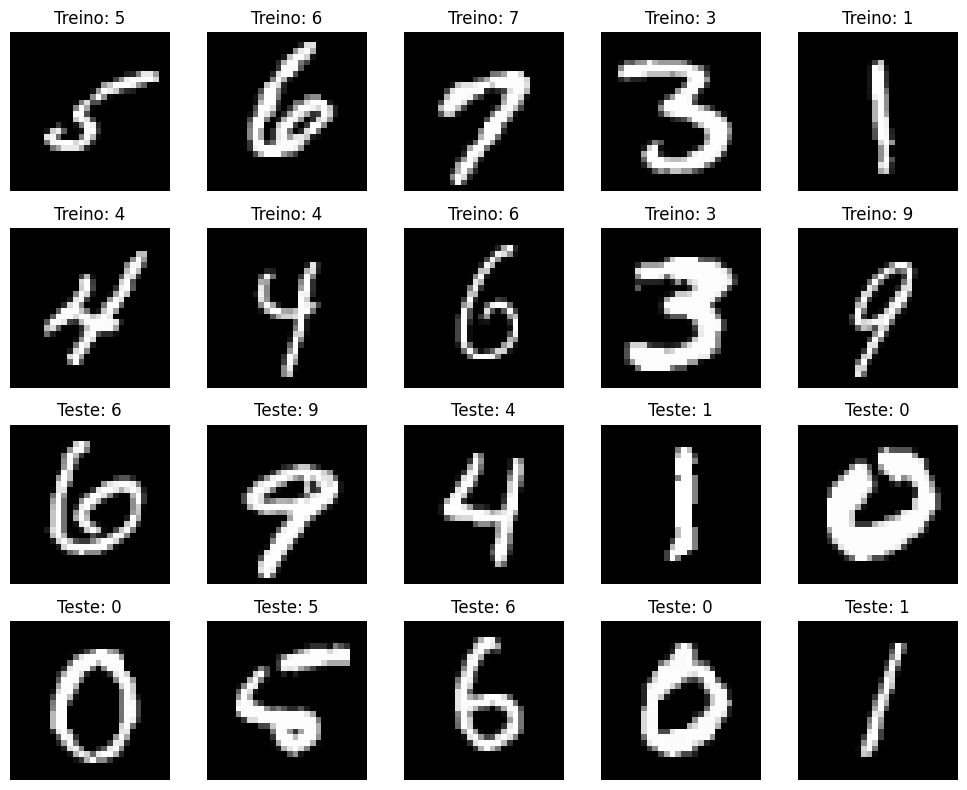

In [27]:
# Selecionar 10 imagens aleatórias do treino
X_train, y_train = next(iter(train_dataloader))
train_indices = torch.randperm(len(X_train))[:10]

# Selecionar 10 imagens aleatórias do teste
X_test, y_test = next(iter(test_dataloader))
test_indices = torch.randperm(len(X_test))[:10]


# Criar uma figura com 20 imagens
fig, axes = plt.subplots(4, 5, figsize=(10, 8))

# Imagens de treino
for ax, idx in zip(axes[0:2].flat, train_indices):
    ax.imshow(X_train[idx].squeeze(), cmap="gray")
    ax.set_title(f"Treino: {y_train[idx].item()}")
    ax.axis("off")

# Imagens de teste
for ax, idx in zip(axes[2:4].flat, test_indices):
    ax.imshow(X_test[idx].squeeze(), cmap="gray")
    ax.set_title(f"Teste: {y_test[idx].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

#Modelo

##Definição do Modelo

In [28]:
class MNIST_MLP(nn.Module):

  def __init__(self):
    super().__init__()

    self.n = 10 #numero de classes que serão identificadas no MNIST(de 0-9)

    ## Definição da Rede
    self.network = nn.Sequential(
      nn.Flatten() #Cada para transformar os pixels em uma lista 2d
      ,nn.Linear(28*28,50) # 28 * 28 é o tamanho total da img(está em lista), e 50 é a quantidade de saidas(neuronios)
      ,nn.ReLU()
      ,nn.Linear(50,self.n)
    )

  def forward(self,x):
    return self.network(x)

##Definindo Função de Custo

In [29]:
criterion = nn.CrossEntropyLoss()

OBS: Foi colocado a Cross Entropy para não ser necessario realizar o hot encoding. O Cross Entropy juntamente com a função ReLU ja são capazes de convergirem

##Olhar a rede e ve se esta configurada corretamente

In [30]:
model = MNIST_MLP()

optimizer = torch.optim.Adam(
    model.parameters()
)

print(model)

MNIST_MLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=50, bias=True)
    (2): ReLU()
    (3): Linear(in_features=50, out_features=10, bias=True)
  )
)


##Treinamento do *Modelo*

In [36]:
epochs = 5 #Quantas epocas serão feitas para testar o modelo

for epoch in range(epochs):

  model.train()

  for x, y in train_dataloader:

    #Forward-pass
    pred = model(x)

    #Calcula o Erro do modelo
    loss = criterion(pred,y)

    #Backpropagation
    loss.backward()

    #Atualiza os Pesos do modelo
    optimizer.step()

    #Zera os gradientes
    optimizer.zero_grad()

  print(f"Epoch {epoch + 1}/{epochs} - Loss: {loss.item():.4f}")

Epoch 1/5 - Loss: 0.0771
Epoch 2/5 - Loss: 0.1738
Epoch 3/5 - Loss: 0.1558
Epoch 4/5 - Loss: 0.0569
Epoch 5/5 - Loss: 0.0036


##Avaliando o Resultado do modelo

In [37]:
model.eval()

#Testando a acurracia do modelo
test_loss = 0
correct = 0
total = 0

with torch.no_grad():

  for x , y in test_dataloader:

    pred = model(x)

    loss = criterion(pred , y)

    test_loss += loss.item()

    predicted = pred.argmax(dim=1)

    correct += (predicted == y).sum().item()

    total += y.size(0)

test_loss /= len(test_dataloader)
accuracy = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.0966
Test Accuracy: 0.9715


##Verificar o dado e o valor predito

In [38]:
def testar_imagem(model, dataset):

    random_index = np.random.randint(0, len(dataset))

    image, true_label = dataset[random_index]

    model.eval()

    with torch.no_grad():
        output = model(image.unsqueeze(0))
        predicted_label = output.argmax(dim=1).item()

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(
        f"Rótulo verdadeiro: {true_label} | "
        f"Rótulo predito: {predicted_label}"
    )
    plt.axis("off")
    plt.show()

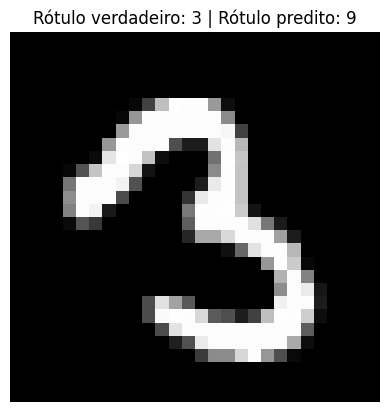

In [73]:
testar_imagem(model,test_data)